<h1 style = 'color: red'>Practice Project: Titanic Survival Prediction</h1>

<h3 style = 'color: yellow'>import required libraries</h3>

In [1]:
# fundamental libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# datasets
from sklearn.datasets import load_iris
# model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
# data preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# lower the amount of features
from sklearn.decomposition import PCA
# modeling
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# pipeline
from sklearn.pipeline import Pipeline
# visualization
import seaborn as sns
# linear model
from sklearn.linear_model import LogisticRegression
# grading
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
#
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

<h3 style = 'color: yellow'>titanic passenger dataset</h3>

In [2]:
# there is function named load_dataset in sns library for testing and sampling
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
titanic = titanic.dropna(subset = ['age'])

In [9]:
titanic.count()

survived       714
pclass         714
sex            714
age            714
sibsp          714
parch          714
fare           714
embarked       712
class          714
who            714
adult_male     714
deck           184
embark_town    712
alive          714
alone          714
dtype: int64

In [10]:
# drop some inrelevant features and missing values
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'
x = titanic[features]
# drop rows with missing value of age
y = titanic[target]

In [11]:
x.head()

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,alone
0,3,male,22.0,1,0,7.2500,Third,man,True,False
1,1,female,38.0,1,0,71.2833,First,woman,False,False
2,3,female,26.0,0,0,7.9250,Third,woman,False,True
3,1,female,35.0,1,0,53.1000,First,woman,False,False
4,3,male,35.0,0,0,8.0500,Third,man,True,True


<h3 style = 'color: yellow'>exercise 1: how balanced are the classes?</h3>

In [13]:
y.value_counts()

survived
0    424
1    290
Name: count, dtype: int64

<h3 style = 'color: yellow'>exercise 2: split the data into training and testing sets</h3>

In [14]:
# since it is quite an imbalance dataset, we need to use stratify for cross-validation
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [15]:
x.head(20)

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,alone
0,3,male,22.0,1,0,7.2500,Third,man,True,False
1,1,female,38.0,1,0,71.2833,First,woman,False,False
2,3,female,26.0,0,0,7.9250,Third,woman,False,True
3,1,female,35.0,1,0,53.1000,First,woman,False,False
4,3,male,35.0,0,0,8.0500,Third,man,True,True
6,1,male,54.0,0,0,51.8625,First,man,True,True
7,3,male,2.0,3,1,21.0750,Third,child,False,False
8,3,female,27.0,0,2,11.1333,Third,woman,False,False
9,2,female,14.0,1,0,30.0708,Second,child,False,False
10,3,female,4.0,1,1,16.7000,Third,child,False,False


<h3 style = 'color: yellow'>define preprocessing transformers for numerical and categorical features</h3>
<h3 style = 'color: yellow'>automatically detect numerical and categorical columns and assign them to separate features</h3>

In [19]:
numerical_features = x_train.select_dtypes(include = ['number']).columns.tolist()
categorical_features = x_train.select_dtypes(include = ['object', 'category']).columns.tolist()

<h3 style = 'color: yellow'>define separate preprocessing pipelines for both feature types</h3>

In [23]:
# define two different pipeline for data preprocessing and such mini pipeline will then later merge into whole pipeline
numerical_transformer = Pipeline(steps = [('imputer', SimpleImputer(strategy = 'median')),
                                          ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps = [('imputer', SimpleImputer(strategy = 'most_frequent')),
                                            ('onehot', OneHotEncoder(handle_unknown = 'ignore'))])

<h3 style = 'color: yellow'>combine the transformers into a single column transformer</h3>

In [25]:
# think of column transformer as a combination tool that combine above mini pipelines
preprocessor = ColumnTransformer(transformers = [('num', numerical_transformer, numerical_features),
                                                 ('cat', categorical_transformer, categorical_features)])

<h3 style = 'color: yellow'>create a model pipeline</h3>

In [26]:
pipeline = Pipeline(steps = [('preprocessor', preprocessor),
                             ('classifier', RandomForestClassifier(random_state = 42))])

<h3 style = 'color: yellow'>define a parameter grid</h3>

In [27]:
# parameter grid is for GridSearchCV later
# classifier__ (double underscore) means that it tells GridSearchCV that such label shall tune the parameters
# n_estimators: number of decision tree
# max_depth: the depth of each tree
# min_samples_split: Minimum number of samples needed to split an internal node
param_grid = {'classifier__n_estimators': [50, 100],
              'classifier__max_depth': [None, 10, 20],
              'classifier__min_samples_split': [2, 5]}

<h3 style = 'color: yellow'>perform grid search cross-validation and fit the best model to the training data</h3>

In [28]:
# cross-validation method
cv = StratifiedKFold(n_splits = 5, shuffle = True)

<h3 style = 'color: yellow'>exercise 3: train the pipeline model</h3>

In [29]:
model = GridSearchCV(estimator = pipeline, param_grid = param_grid, cv = cv, scoring = 'accuracy', verbose = 2)
model.fit(x_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'class',
                                                                          'who'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

<h3 style = 'color: yellow'>exercise 4: get the model predictions from the grid search estimator on the unseen data</h3>

In [30]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79        85
           1       0.70      0.66      0.68        58

    accuracy                           0.75       143
   macro avg       0.74      0.73      0.74       143
weighted avg       0.75      0.75      0.75       143



<h3 style = 'color: yellow'>exercise 5: plot the confusion matrix</h3>

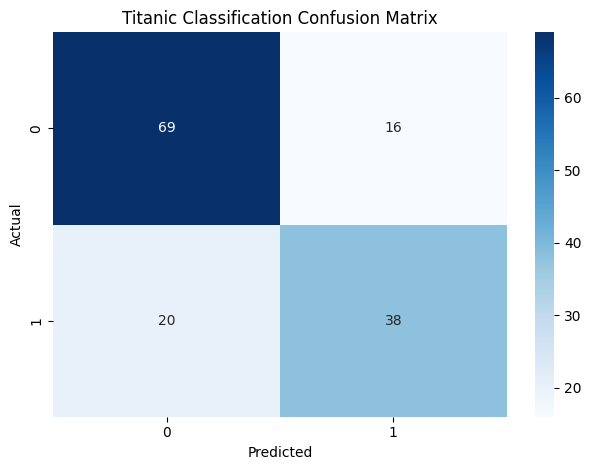

In [31]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd')
# set the title and labels
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
# show the plot
plt.tight_layout()
plt.show()

<h3 style = 'color: yellow'>feature importances</h3>

In [35]:
# trace back the categorical features
# don't need to trace back through the pipeline for the numerical features, bcuz we didn't transform them into new ones
model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

In [36]:
model.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'class', 'who'])])),
                ('classifier',
                 RandomForestClassifier(min_samples_split=5, n_estimators=50,
                                        random_state=42))])

In [37]:
feature_importances = model.best_estimator_['classifier'].feature_importances_
# combine the numerical and one-hot encoded categorical feature names
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                          .named_transformers_['cat']
                                          .named_steps['onehot']
                                          .get_feature_names_out(categorical_features))

In [38]:
feature_names

['pclass',
 'age',
 'sibsp',
 'parch',
 'fare',
 'sex_female',
 'sex_male',
 'class_First',
 'class_Second',
 'class_Third',
 'who_child',
 'who_man',
 'who_woman']

<h3 style = 'color: yellow'>display the feature importances in a bar plot</h3>

In [39]:
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances}).sort_values(by = 'Importance', ascending = False)
importance_df

,Feature,Importance
4,fare,0.214446
1,age,0.198552
6,sex_male,0.135939
11,who_man,0.091460
5,sex_female,0.082507
9,class_Third,0.057526
0,pclass,0.050371
2,sibsp,0.047211
12,who_woman,0.035902
7,class_First,0.026427


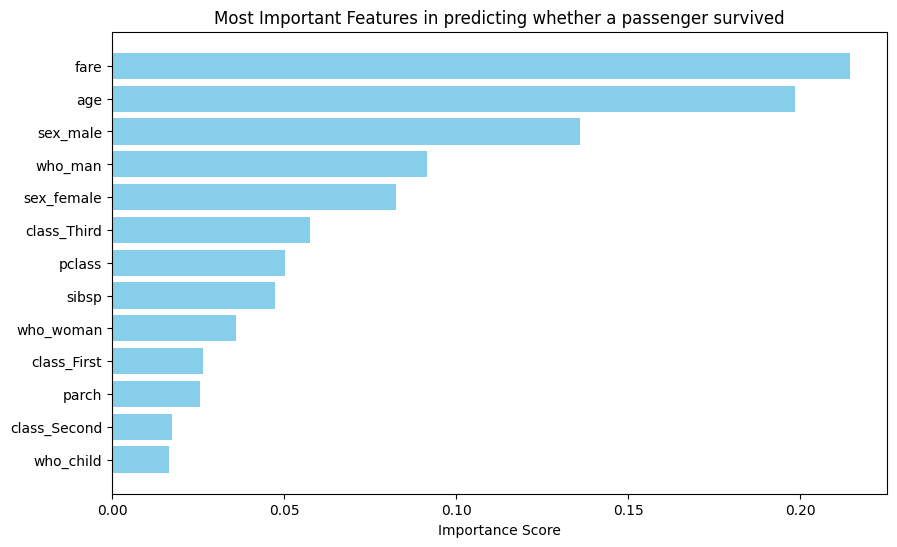


Test set accuracy: 74.83%


In [44]:
# plotting
plt.figure(figsize = (10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color = 'skyblue')
plt.gca().invert_yaxis()
plt.title('Most Important Features in predicting whether a passenger survived')
plt.xlabel('Importance Score')
plt.show()
# print test score
test_score = model.score(x_test, y_test)
print(f'\nTest set accuracy: {test_score:.2%}')